In [13]:
from sklearn.mixture import GaussianMixture
import seaborn as sns
import matplotlib.pyplot as plt
import vtk
import numpy as np
import glob
import sys
import os
import pandas as pd
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile, ReadVTKFile


In [5]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

nr_path = '/Volumes/T7_Research/CABG/05_PrePostCABG/NonRegistered'
VTKFiles = sorted(glob.glob(f"{nr_path}/*.vtk"))

['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

In [6]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [7]:
def GetScalarArrayName (Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_
        


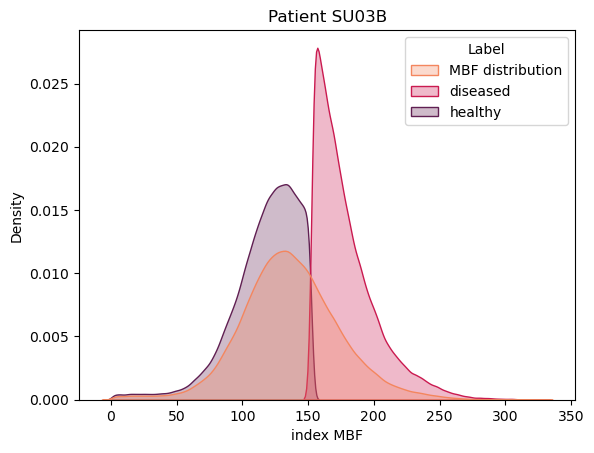

In [19]:
patient_id = 'SU03'

VTKFiles = np.array(VTKFiles)
out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
MBF_B_array = MBF_B_array[MBF_B_array > 0]

gmm = GaussianMixture(n_components=2).fit(MBF_B_array.reshape(-1,1))
labels = gmm.predict(MBF_B_array.reshape(-1,1))

diseased = MBF_B_array[labels == 0]
healthy = MBF_B_array[labels == 1]

df = pd.DataFrame({
    'MBF':np.concatenate([MBF_B_array, diseased, healthy]),
    'Label': ['MBF distribution'] * len(MBF_B_array) +
             ['diseased'] * len(diseased) +
             ['healthy'] * len(healthy)
})

plt.figure()
sns.kdeplot(data=df, x="MBF", hue='Label',
                fill=True, common_norm=False, palette="rocket_r",
            alpha=.3, linewidth=1)
plt.xlabel('index MBF')
plt.title(f"Patient {patient_id}B")
#plt.xlim((0, 2))
plt.show()

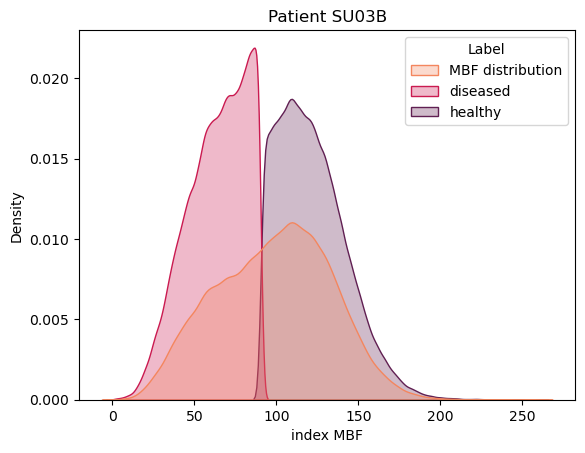

In [20]:
out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
MBF_A_array = MBF_A_array[MBF_A_array > 0]

gmm = GaussianMixture(n_components=2).fit(MBF_A_array.reshape(-1,1))
labels = gmm.predict(MBF_A_array.reshape(-1,1))

diseased = MBF_A_array[labels == 0]
healthy = MBF_A_array[labels == 1]

df = pd.DataFrame({
    'MBF':np.concatenate([MBF_A_array, diseased, healthy]),
    'Label': ['MBF distribution'] * len(MBF_A_array) +
             ['diseased'] * len(diseased) +
             ['healthy'] * len(healthy)
})

plt.figure()
sns.kdeplot(data=df, x="MBF", hue='Label',
                fill=True, common_norm=False, palette="rocket_r",
            alpha=.3, linewidth=1)
plt.xlabel('index MBF')
plt.title(f"Patient {patient_id}B")
#plt.xlim((0, 2))
plt.show()

In [ ]:
Removed_Cases = ["SU25", "VA04"]

stats = []
for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    print(patient_id)
    VTKFiles = np.array(VTKFiles)
    out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
    MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
    MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_B_array = MBF_B_array[MBF_B_array > 0]
    index_MBF_B = MBF_B_array/np.percentile(MBF_B_array, 75)

    out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
    MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
    MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_A_array = MBF_A_array[MBF_A_array > 0]
    index_MBF_A = MBF_A_array/np.percentile(MBF_A_array, 75)

    stats.append({'case': patient_id, 'median_A': np.median(index_MBF_A), 'median_B': np.median(index_MBF_B), 'is_ischemic':False})

    df = pd.DataFrame({
        'MBF':np.concatenate([index_MBF_A, index_MBF_B]),
        'Label': ['raw baseline MBF'] * len(MBF_A_array) +
                ['raw follow-up MBF'] * len(MBF_B_array)
    })

    plt.figure()
    sns.kdeplot(data=df, x="MBF", hue='Label',
                    fill=True, common_norm=False, palette="rocket_r",
                alpha=.3, linewidth=1, clip=(0, 2))
    plt.xlabel('index MBF')
    plt.title(f"Patient {patient_id}")
    plt.xlim((0, 2))
    plt.show()
